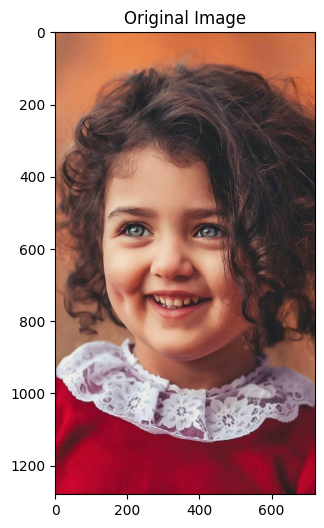

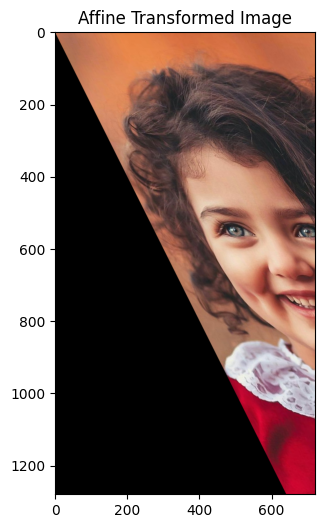

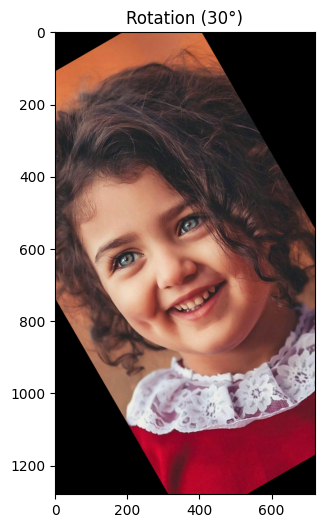

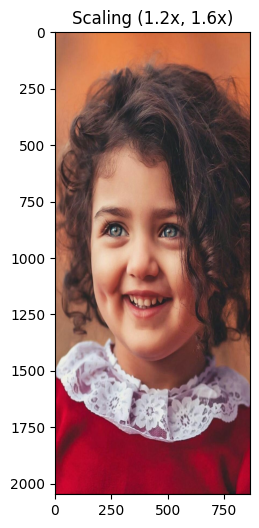

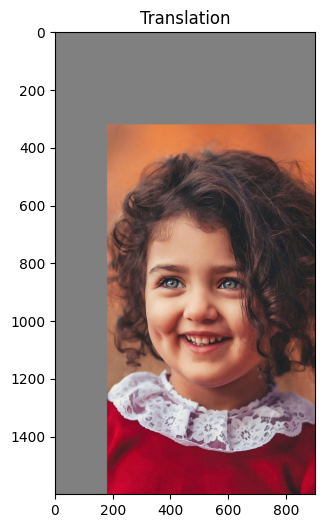

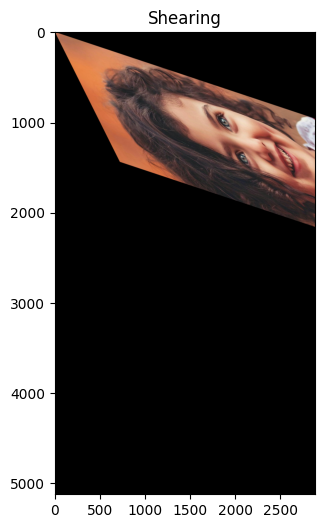

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Read original image ---
I = cv2.imread('pk.jpg')
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)   # Convert BGR → RGB for display
plt.figure(figsize=(6,6))
plt.imshow(I)
plt.title('Original Image')
plt.axis('on')

h, w = I.shape[:2]

# --- 1. Affine Transformation Example ---
pts1 = np.float32([[0,0], [w-1,0], [0,h-1]])
pts2 = np.float32([[0,0], [w-1,0], [int(0.5*h), h-1]])  # Shear on Y
M_affine = cv2.getAffineTransform(pts1, pts2)
J = cv2.warpAffine(I, M_affine, (w, h))
plt.figure(figsize=(6,6))
plt.imshow(J)
plt.title('Affine Transformed Image')
plt.axis('on')

# --- 2. Rotation (30 degrees) ---
angle = 30
M_rotate = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
Ia = cv2.warpAffine(I, M_rotate, (w, h))
plt.figure(figsize=(6,6))
plt.imshow(Ia)
plt.title('Rotation (30°)')
plt.axis('on')

# --- 3. Scaling (x1.2, y1.6) ---
scale_x, scale_y = 1.2, 1.6
M_scale = np.float32([[scale_x, 0, 0],
                      [0, scale_y, 0]])
Ib = cv2.warpAffine(I, M_scale, (int(w*scale_x), int(h*scale_y)))
plt.figure(figsize=(6,6))
plt.imshow(Ib)
plt.title('Scaling (1.2x, 1.6x)')
plt.axis('on')

# --- 4. Translation (0.25 * width, 0.25 * height) ---
tx, ty = 0.25 * w, 0.25 * h
M_trans = np.float32([[1, 0, tx],
                      [0, 1, ty]])
Ic = cv2.warpAffine(I, M_trans, (w + int(tx), h + int(ty)), borderValue=(128,128,128))
plt.figure(figsize=(6,6))
plt.imshow(Ic)
plt.title('Translation')
plt.axis('on')

# --- 5. Shearing ---
M_shear = np.float32([[1, 3, 0],
                      [2, 1, 0]])
Id = cv2.warpAffine(I, M_shear, (w*4, h*4))  # enlarge output size
plt.figure(figsize=(6,6))
plt.imshow(Id)
plt.title('Shearing')
plt.axis('on')

plt.show()


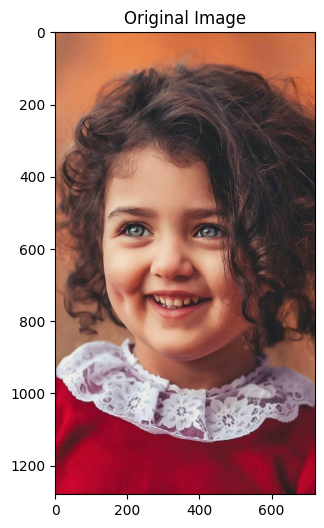

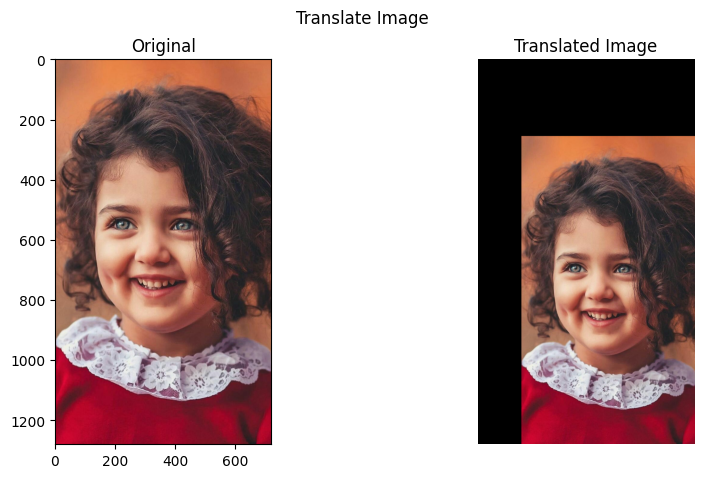

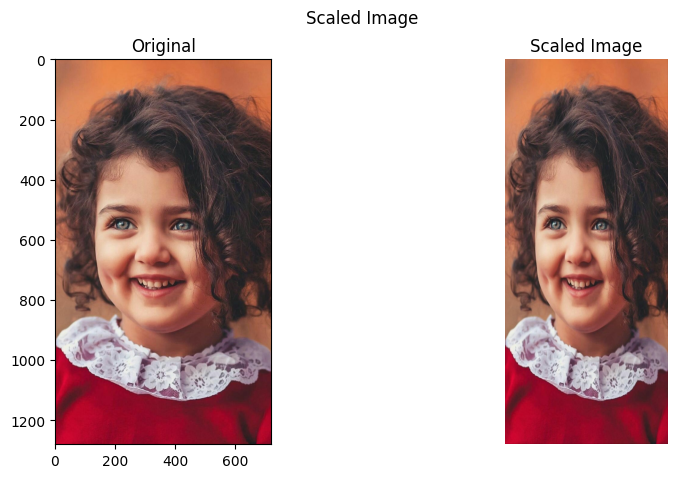

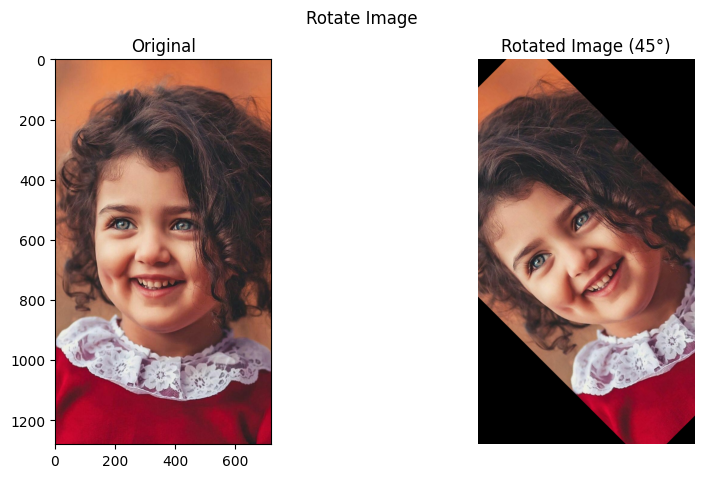

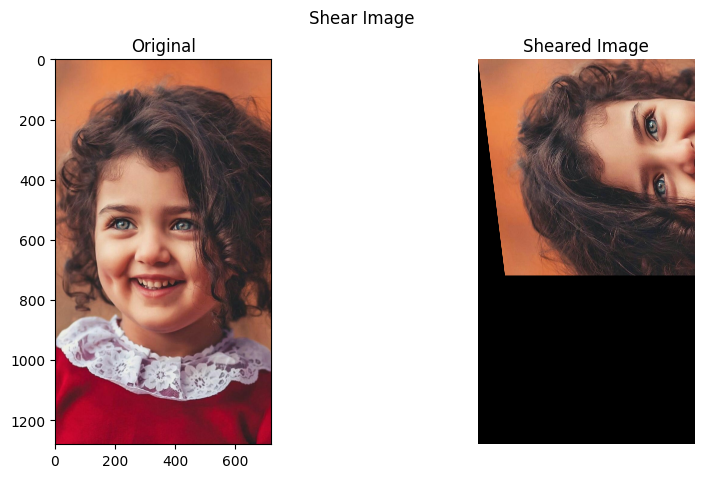

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load the original image ---
I = cv2.imread('pk.jpg')
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB for display
h, w = I.shape[:2]

plt.figure(figsize=(6,6))
plt.imshow(I)
plt.title('Original Image')
plt.axis('on')

# --- Scaling factors ---
Sx, Sy, Sz = 1.2, 1.6, 2.4

# ======================================================
# 1️⃣ Translation
# ======================================================
tx, ty = 0.25 * w, 0.25 * h
M_translate = np.float32([[1, 0, tx],
                          [0, 1, ty]])
translated = cv2.warpAffine(I, M_translate, (int(w + tx), int(h + ty)))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(I), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(translated), plt.title('Translated Image')
plt.suptitle('Translate Image')
plt.axis('off')

# ======================================================
# 2️⃣ Scaling
# ======================================================
M_scale = np.float32([[Sx, 0, 0],
                      [0, Sy, 0]])
scaled = cv2.warpAffine(I, M_scale, (int(w*Sx), int(h*Sy)))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(I), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(scaled), plt.title('Scaled Image')
plt.suptitle('Scaled Image')
plt.axis('off')

# ======================================================
# 3️⃣ Rotation (45 degrees)
# ======================================================
theta = 45
M_rotate = cv2.getRotationMatrix2D((w/2, h/2), theta, 1)
rotated = cv2.warpAffine(I, M_rotate, (w, h))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(I), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(rotated), plt.title('Rotated Image (45°)')
plt.suptitle('Rotate Image')
plt.axis('off')

# ======================================================
# 4️⃣ Shearing
# ======================================================
M_shear = np.float32([[1, 8, 0],
                      [8, 0, 0]])
# Increase canvas size to accommodate extreme shear
sheared = cv2.warpAffine(I, M_shear, (w*8, h*8))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(I), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(sheared), plt.title('Sheared Image')
plt.suptitle('Shear Image')
plt.axis('off')

plt.show()


In [ ]:
import cv2
import numpy as np

origenal = cv2.imread('Images/feather.jpg', 0)
cv2.imshow('original_image', origenal)
width, height = origenal.shape
print(width, height)

#--------------------<Image Translation>--------------------#
Tx = 100
Ty = 0
Transformation_Matrix = np.float32([[1, 0, -Tx], [0, 1, Ty]])
transformed_image = cv2.warpAffine(origenal, Transformation_Matrix, origenal.shape[::-1])
cv2.imshow('Transformed_image', transformed_image)

#--------------------<Image Reflection>--------------------#
M_Horizontal = np.float32([[1,  0, 0], [0, -1, width], [0,  0, 1]])
M_Vertical = np.float32([[-1, 0, height], [0, 1, 0], [0, 0, 1]])

reflected_hor = cv2.warpPerspective(origenal, M_Horizontal, (int(height), int(width)))
reflected_ver = cv2.warpPerspective(origenal, M_Vertical, (int(height), int(width)))
cv2.imshow('ReflectedImageHor', reflected_hor)
cv2.imshow('ReflectedImageVer', reflected_ver)

#--------------------<Image Rotation>--------------------#
# M_Rotation = np.float32([[1,  0, 0], [0, -1, width], [0,  0, 1]])
img_rotation = cv2.warpAffine(origenal, cv2.getRotationMatrix2D((height/2, width/2), 30, 0.6), (height, width))
cv2.imshow('imgRotation', img_rotation)

#--------------------<Image Shrink>--------------------#
img_shrinked = cv2.resize(origenal, (200, 100), interpolation = cv2.INTER_AREA) 
cv2.imshow('imgShrinked', img_shrinked)

#--------------------<Image Enlarged>--------------------#
img_enlarged = cv2.resize(origenal, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
cv2.imshow('imgEnlarged', img_enlarged)

#--------------------<Image croped>--------------------#
cropped_img = origenal[0:150, 50:194]
cv2.imshow('imgCropped', cropped_img)

#--------------------<Image shearing>--------------------#
M_ShearingX = np.float32([[1, 0.5, 0], [0, 1, 0], [0, 0, 1]])
sheared_img = cv2.warpPerspective(origenal, M_ShearingX, (int(height*1.5), int(width*1.5)))
cv2.imshow('imgShearingX', sheared_img)

M_ShearingY = np.float32([[1, 0, 0], [0.5, 1, 0], [0, 0, 1]])
sheared_img = cv2.warpPerspective(origenal, M_ShearingY, (int(height*1.5), int(width*1.5)))
cv2.imshow('imgShearingY', sheared_img)


#making the program wait for a key before treminating
cv2.waitKey(0)
cv2.destroyAllWindows()

259 194
